In [55]:
#Necessary Library
#David
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential 
from keras.layers import LSTM, Dropout, Dense
from stocker.predict import tomorrow
import os #accessing directory structure

In [62]:
#Load Dataset
def loadData(fileLocation):
    df = pd.read_csv(fileLocation, delimiter = ',')
    df.columns=['Date','Open','High','Low','Close','Volumn','OpenInt']
    return df

In [106]:
#Cleaning Up Dataset
from sklearn.preprocessing import MinMaxScaler
def cleanData(df):
    df.drop('OpenInt',inplace=True, axis=1)
    data_value=df.values
    scaler=MinMaxScaler(feature_range=(0,1))
    data_scaled=scaler.fit_transform(data_value)
    data_reframed=seriesToSupervised(data_scaled)
    return data_reframed

In [111]:
def seriesToSupervised(df, nIn=1,nOut=1,dropNan=True):
    nVars=1 if type(df) is list else df.shape[1]
    df=pd.DataFrame(df)
    cols, names=list(),list()
    for i in range(nIn, 0, -1):
        cols.append(df.shift(-i))
        names+=[('var%d(t-%d)' % (j+1,i)) for j in range(nVars)]
    for i in range(0, nOut):
        cols.append(df.shift(-i))
        if(i==0):
            names+=[('var%d(t)' % (j+1)) for j in range(nVars)]
        else:
            names+=[('var%d(t+%d)' % (j+1)) for j in range(nVars)]
        data=pd.concat(cols, axis=1)
        data.columns=names
        if dropNan:
            data.dropna(inplace=True)
        return data


In [118]:
#Split Dataset into Training and Validation Data
def splitData(df):
 
    #x_train, x_test_val, y_train, y_test_val=train_test_split(x,y,random_state=50, test_size=0.3)
    # x_test, x_val, y_test, y_val= train_test_split(x_test_val, y_test_val, test_size=50)
    # print(x_train.shape, y_train.shape)
    num=int(df.shape[0]*0.7)
    value=df.values
    train=value[:num,:]
    test=value[num:,:]
    
    x_train, y_train=train[:,:-1], train[:,-1]
    x_test, y_test=test[:,:-1], test[:,-1]
    
    x_train=x_train.reshape((x_train.shape[0], 1, x_train.shape[1]))
    x_test= x_test.reshape((x_test.shape[0], 1, x_test.shape[1]))

    print(x_train.shape, x_test.shape)
    print(y_train.shape, y_test.shape)
    return x_train, y_train, x_test, y_test

In [114]:
#Open dataset
df=loadData("Data/ETFs/aadr.us.txt")
df.head()

,Date,Open,High,Low,Close,Volumn,OpenInt
0,2010-07-21,24.333,24.333,23.946,23.946,43321,0
1,2010-07-22,24.644,24.644,24.362,24.487,18031,0
2,2010-07-23,24.759,24.759,24.314,24.507,8897,0
3,2010-07-26,24.624,24.624,24.449,24.595,19443,0
4,2010-07-27,24.477,24.517,24.431,24.517,8456,0


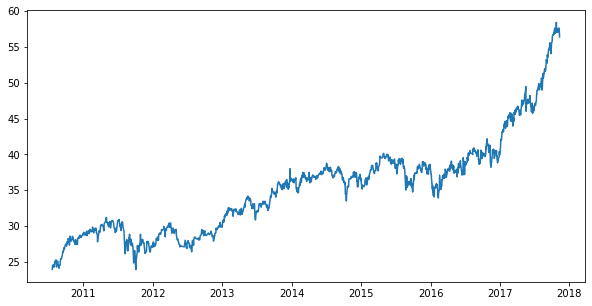

In [115]:
df['Date']=pd.to_datetime(df.Date,format="%Y-%m-%d")
df=df.set_index('Date')
plt.figure(figsize=(10,5))
plt.plot(df["Close"], label="Close Price History")

In [116]:
df=cleanData(df)

In [117]:
df.head()

,var1(t-1),var2(t-1),var3(t-1),var4(t-1),var5(t-1),var1(t),var2(t),var3(t),var4(t),var5(t)
0,0.020413,0.020072,0.014631,0.015688,0.169865,0.011446,0.011129,0.002335,0.000000,0.408142
1,0.023729,0.023380,0.013212,0.016268,0.083807,0.020413,0.020072,0.014631,0.015688,0.169865
2,0.019836,0.019497,0.017202,0.018820,0.183169,0.023729,0.023380,0.013212,0.016268,0.083807
3,0.015598,0.016420,0.016670,0.016558,0.079652,0.019836,0.019497,0.017202,0.018820,0.183169
4,0.015598,0.016420,0.014335,0.014064,0.046779,0.015598,0.016420,0.016670,0.016558,0.079652


In [119]:
x_train, y_train, x_test, y_test=splitData(df)

(1094, 1, 9) (470, 1, 9)
(1094,) (470,)


In [ ]:
#for dirName, _, fileNames in os.walk('Data'):
 #   for fileName in fileNames:
  #      dataset+=os.path.join(dirName,fileName)

In [123]:
#Algorithm
#Paula, John, Litepup

#LSTM Model
LSTMModel=Sequential()
LSTMModel.add(LSTM(120, input_shape=(x_train.shape[1], x_train.shape[2]), return_sequences=True))
LSTMModel.add(LSTM(50, return_sequences=True))
LSTMModel.add(Dropout(0.3))
LSTMModel.add(LSTM(15))
LSTMModel.add(Dense(2))
LSTMModel.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 1, 120)            62400     
                                                                 
 lstm_1 (LSTM)               (None, 1, 50)             34200     
                                                                 
 dropout (Dropout)           (None, 1, 50)             0         
                                                                 
 lstm_2 (LSTM)               (None, 15)                3960      
                                                                 
 dense (Dense)               (None, 2)                 32        
                                                                 
Total params: 100,592
Trainable params: 100,592
Non-trainable params: 0
_________________________________________________________________


In [ ]:
#Testing Accuracy
#Jacob